# Gamma-Gospel — a quantitative teardown 🔬
### GEX construction · unobservable dealer assumption · HAC nested regression · baked-in-β recovery · the VIX trenchcoat

![Signal: Pre-reg](https://img.shields.io/badge/Signal-Pre--reg-8b949e?style=flat-square)
![Tradability: Pre-reg](https://img.shields.io/badge/Tradability-Pre--reg-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) — *same seven beats.* **Pre-registered** thesis: the GEX-regime claim contains a real but modest dealer-gamma effect **largely confounded by the volatility level** — a raw negative-gamma gap in realised vol and directional efficiency that mostly collapses once VIX is partialled out — and rests on an **unobservable dealer-positioning assumption** (long calls / short puts) we flag rather than hide.

> ⚠️ **Not investment advice.** Pre-registered design. Executed here on the **synthetic tape** — two panels sharing a VIX-driven confound, one with a baked-in genuine gamma effect (`beta_de=0.06`, `beta_vol=0.002`) and one with none — where the nested HAC regression recovers exactly what we put in (fixed seeds, no network); the real SPY-chain stamps come from [`examples/verify.py`](../examples/verify.py) → [`../docs/results.md`](../docs/results.md), literature in [`../docs/references.md`](../docs/references.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back into intuition. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))           # study root (gamma_gospel/ lives there)
sys.path.insert(0, os.path.abspath("../../.."))      # repo root, for quantlab
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (9.5, 5.2)
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
from gamma_gospel import data, signals, decompose

# Two offline tapes that share a VIX-driven confound (VIX moves BOTH the GEX sign and the day's
# character). REAL has a genuine gamma effect baked on top (beta_de=0.06); TRENCH has none.
real, t_real = data.synthetic_panel(beta_vol=0.0020, beta_de=0.060, seed=0)
trench, t_tr = data.synthetic_panel(beta_vol=0.0, beta_de=0.0, seed=0)
neg = real["neg_gamma"].astype(bool)
print(f"{len(real)} sessions | VIX on neg-gamma days {real.loc[neg,'vix'].mean():.1f} "
      f"vs pos {real.loc[~neg,'vix'].mean():.1f} | baked-in beta_de REAL={t_real.beta_de}, "
      f"TRENCH={t_tr.beta_de}")


750 sessions | VIX on neg-gamma days 21.4 vs pos 13.7 | baked-in beta_de REAL=0.06, TRENCH=0.0


## 1 · The construction, and its load-bearing assumption

GEX is **not observed** — it is *assumed*. Under the SqueezeMetrics / retail convention customers buy index puts and overwrite calls, so dealers are long call gamma and short put gamma:

$$\text{GEX} = \sum_{\text{calls}} \Gamma_i\, \text{OI}_i\, \cdot 100 \cdot S^2 \;-\; \sum_{\text{puts}} \Gamma_i\, \text{OI}_i\, \cdot 100 \cdot S^2.$$

Only the **sign** is load-bearing here. `compute_gex` implements it; flipping the call/put open-interest weight flips the sign deterministically, which is what the unit-tests assert. The dealer-direction assumption is the single biggest modelling risk — if real dealer inventory differs, the whole map inverts.

In [2]:
call_heavy = data.synthetic_chain(call_oi_scale=2.0, put_oi_scale=1.0, seed=1)
put_heavy = data.synthetic_chain(call_oi_scale=1.0, put_oi_scale=2.0, seed=1)
print('call-heavy chain GEX:', round(data.compute_gex(call_heavy, 100.0)['gex'], 3), '(>0, long gamma)')
print('put-heavy  chain GEX:', round(data.compute_gex(put_heavy, 100.0)['gex'], 3), '(<0, short gamma)')

call-heavy chain GEX: 0.017 (>0, long gamma)
put-heavy  chain GEX: -0.016 (<0, short gamma)


## 1b · The data-generating process (so we know the truth)

The synthetic bakes the exact structure the real study must untangle:

- a persistent **VIX** regime (AR(1)) — *observable*;
- `P(neg_gamma) = logistic(γ·(VIX − VIX̄))` — high VIX ⇒ put-heavy ⇒ negative gamma (**the confound**: VIX drives the regime label);
- `rv = a + s·VIX + β_vol·neg_gamma + ε` and `de = clip(c + u·VIX + β_de·neg_gamma + η)` — each outcome rises with VIX *and*, by `β`, with negative gamma **independently** of VIX.

So the raw gap is real by construction, but only the `β` part is *GEX's own*. The whole verdict is recovering `β` after removing VIX.

In [3]:
print('confound check — mean VIX by regime:')
print(real.groupby(real['neg_gamma'].astype(bool))['vix'].mean().rename({False:'pos-gamma', True:'neg-gamma'}))

confound check — mean VIX by regime:
neg_gamma
pos-gamma   13.7185
neg-gamma   21.4257
Name: vix, dtype: float64


## 3–4 · The nested regression — the load-bearing number

`partial_over_vix` fits `y ~ vix` and `y ~ vix + neg_gamma` with Newey-West (HAC) errors (daily, persistent regimes → naive *t* overstates). It returns the raw gap, the **surviving** negative-gamma coefficient, its HAC *t*, the incremental R², and the share of the raw gap that survives. On the real-effect panel it recovers `β`; on the trenchcoat panel it collapses to zero.

In [4]:
rows = []
for name, panel, truth in [('REAL', real, t_real), ('TRENCH', trench, t_tr)]:
    for y in ('rv', 'de'):
        p = decompose.partial_over_vix(panel, y)
        rows.append({'panel': name, 'outcome': y, 'baked_beta': (truth.beta_vol if y=='rv' else truth.beta_de),
                     'raw_gap': p['raw_gap'], 'raw_t': p['raw_t'],
                     'surviving': p['surviving_coef'], 'surv_t': p['surviving_t'],
                     'share_kept': p['survival_share'], 'dR2': p['delta_r2']})
display(pd.DataFrame(rows).set_index(['panel','outcome']).round(4))

baked_beta  raw_gap   raw_t  surviving  surv_t  share_kept  \
panel  outcome                                                               
REAL   rv           0.0020   0.0071 18.3692     0.0018 11.1871      0.2592   
       de           0.0600   0.1494 14.9028     0.0558  4.9495      0.3739   
TRENCH rv           0.0000   0.0051 13.2053    -0.0002 -0.9479     -0.0305   
       de           0.0000   0.0894  8.9159    -0.0042 -0.3691     -0.0466   

                  dR2  
panel  outcome         
REAL   rv      0.0189  
       de      0.0211  
TRENCH rv      0.0002  
       de      0.0001

Read the table: in **REAL**, `surviving` lands on `baked_beta` with |t| ≫ 2 — the genuine effect is recovered. In **TRENCH**, `raw_gap` is just as large (the confound), but `surviving` ≈ 0 with |t| < 2 and `dR2` ≈ 0 — the gap was entirely VIX. The raw column is *identical in character* across the two; only the control distinguishes signal from relabel. This is the exact apparatus pointed at the real chain.

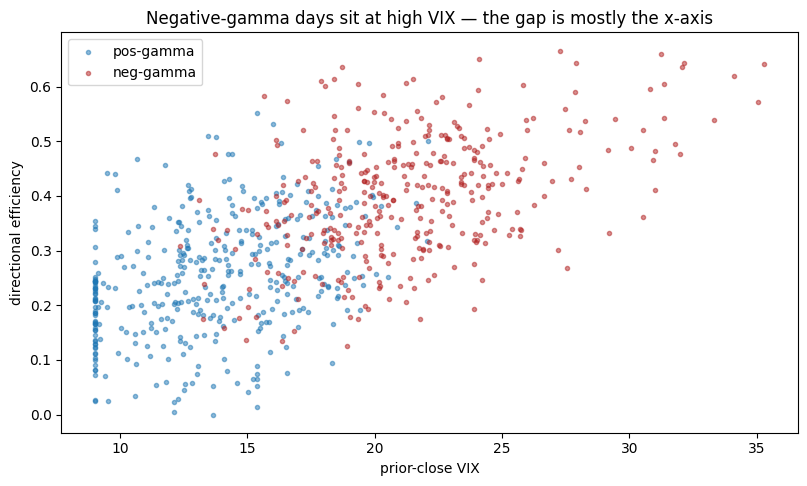

In [5]:
# Why the raw gap is a trap: directional efficiency vs VIX, coloured by regime (REAL panel).
neg = real['neg_gamma'].astype(bool)
plt.scatter(real.loc[~neg,'vix'], real.loc[~neg,'de'], s=9, alpha=0.5, label='pos-gamma', color='#1f77b4')
plt.scatter(real.loc[neg,'vix'], real.loc[neg,'de'], s=9, alpha=0.5, label='neg-gamma', color='#b22222')
plt.xlabel('prior-close VIX'); plt.ylabel('directional efficiency')
plt.title('Negative-gamma days sit at high VIX — the gap is mostly the x-axis'); plt.legend(); plt.show()

## 5 · The verdict, with the numbers *(pre-registered)*

**Signal `WEAK` (expected)** — the raw gap is real but we expect the VIX-controlled coefficient to retain little, especially for range vol (near-tautologically VIX); GEX earns `REAL` only if directional efficiency keeps a significant, material coefficient after VIX. **Tradability `MIRAGE` (expected)** — a surviving sign is a regime *bias*, not an entry; a few points of directional-efficiency tilt do not pay a round-trip options/index spread on a whole-day hold. The synthetic validates the machine; [`../docs/results.md`](../docs/results.md) (via `verify.py`, as-of 2026-06-01) fills the stamps on the real SPY chain.

## 6 · Could you trade it — the cost a regime bias can't pay

Grant a surviving directional-efficiency effect of ~`β_de` on the day. That is a tilt in the *shape* of the session, not a signed entry — to express it you still need a trade, and you pay the spread (per the house rule, costs against the alpha, not the gross). A few points of trend-vs-chop probability, held all day on a near-symmetric return, is swamped by a round-trip SPY-options or index spread. There is no capacity question — SPX options are deep — because the edge, if any, dies on costs before size matters.

## 7 · Going further

- **Walls & flip as levels** — `compute_gex` returns the call/put walls and a crude gamma flip; test whether intraday highs/lows cluster there vs a permutation null (Ni–Pearson–Poteshman pinning is the prior).
- **Intraday character** — replace daily-OHLC directional efficiency with a minute-bar variance ratio / mean-reversion statistic, the pitch's literal claim.
- **Dealer-sign robustness** — re-run under alternative positioning assumptions (e.g. add a 0DTE-only book, or flip the put convention) and see how much the sign series — and the verdict — moves. This is the single biggest modelling risk.
- **Magnitude, not just sign** — does *bigger* |GEX| predict more suppression/amplification, in a continuous regression beyond the sign dummy?

Engine: [`../../../quantlab/`](../../../quantlab/). Method: [`METHODOLOGY.md`](../../../METHODOLOGY.md). Real run: `examples/verify.py` → [`../docs/results.md`](../docs/results.md). Literature: [`../docs/references.md`](../docs/references.md).